# COSETTE codebook usage entropy

$$H_L = -\sum_{c=0}^{255} p_c \log_2 p_c \quad\text{bits}, \qquad
H_L^{norm} = H_L / \log_2 256 = H_L / 8 \in [0, 1].$$



In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'scripts' / 'extensions' / 'beyond_accuracy.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from scripts.extensions.beyond_accuracy import shannon_entropy  # same H used everywhere

K, L = 256, 4
DUMPS = {'Beauty': 'Beauty', 'Sports': 'Sports_and_Outdoors'}
TOPK = REPO / 'reports' / 'extensions' / 'topk'

In [2]:
def usage_counts(path, K=256, L=4):
    """Per-level [K] vectors: counts[L][c] = #items whose level-L code is c."""
    t2i = json.load(open(path))
    counts = np.zeros((L, K), dtype=np.int64)
    for key in t2i:
        for lvl, c in enumerate(int(x) for x in key.split(',')):
            counts[lvl, c] += 1
    return counts

rows = []
for label, slug in DUMPS.items():
    counts = usage_counts(TOPK / slug / 'tuple_to_item.json', K, L)
    for lvl in range(L):
        c = counts[lvl]
        rows.append({
            'dataset': label, 'level': f'L{lvl}',
            'codes_used': int((c > 0).sum()),  # out of 256
            'H_bits': round(shannon_entropy(c, normalize=False), 3),   # of 8 max
            'H_norm': round(shannon_entropy(c, normalize=True), 3),    # H_bits / 8
        })
df = pd.DataFrame(rows)
df

,dataset,level,codes_used,H_bits,H_norm
0,Beauty,L0,256,7.896,0.987
1,Beauty,L1,256,7.913,0.989
2,Beauty,L2,256,7.925,0.991
3,Beauty,L3,256,7.962,0.995
4,Sports,L0,256,7.899,0.987
5,Sports,L1,256,7.905,0.988
6,Sports,L2,256,7.964,0.996
7,Sports,L3,256,7.981,0.998


wrote /home/stas/Desktop/University/RECSYS/rec_sys_cosette_marius/reports/figures/codebook_usage_entropy.png


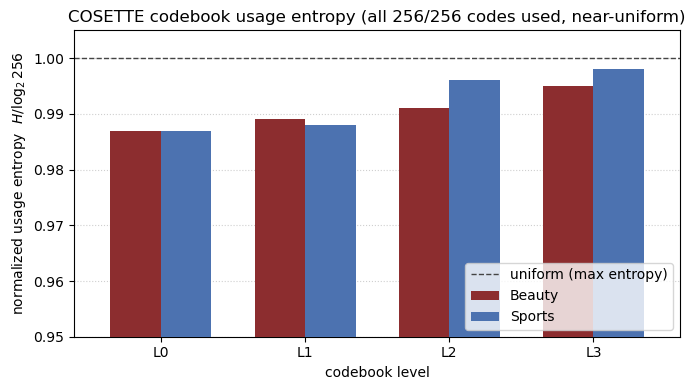

In [3]:
# One plot: per-level normalized usage entropy, both datasets, vs the uniform ceiling.
piv = df.pivot(index='level', columns='dataset', values='H_norm')
ax = piv.plot(kind='bar', figsize=(7, 4), color=['#8c2d2f', '#4C72B0'], width=0.7, zorder=3)
ax.axhline(1.0, ls='--', lw=1, color='#444', zorder=2, label='uniform (max entropy)')
ax.set_ylim(0.95, 1.005)
ax.set_ylabel('normalized usage entropy  $H/\\log_2 256$')
ax.set_xlabel('codebook level')
ax.set_title('COSETTE codebook usage entropy (all 256/256 codes used, near-uniform)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', ls=':', alpha=0.6, zorder=0)
ax.legend(loc='lower right')
plt.tight_layout()
out = REPO / 'reports' / 'figures' / 'codebook_usage_entropy.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150)
print('wrote', out)
plt.show()

**Read-off.** All 256/256 codes are used at every level, and `H_norm` sits at
~0.987 to 0.998 (i.e. 7.90 to 7.98 of 8 bits): usage is essentially uniform. The
tokenizer is healthy, so the catalog-reachability collapse (see EXTENSION_SUMMARY.md)
is not a code-utilization / codebook-collapse artifact. Note this is *marginal* usage
entropy; demand can still be skewed *conditionally* within an L1 prefix.